# Day 117 — Ensemble Methods: Random Forest Depth + Gradient Boosting
**Month 6 | Week 4 | ShopEase 300-row Dataset (seed=42)**

---

| Section | Content |
|---------|---------|
| 1 | Raw Data Setup |
| 2 | Practice Guide — Tasks A → E + ★ Bonus |
| 3 | Concept Notes |
| 4 | Answer Key |
| 5 | Scoring Rubric |

**What you will build today:**
A side-by-side ensemble comparison pipeline — Random Forest (bagging) vs
Gradient Boosting (boosting) — with feature importance analysis, OOB error,
learning-curve interpretation, and a client-ready performance report.
After today, you can explain *why* ensembles beat single trees and *which* to
recommend for a given business problem.


---
## Section 1 — Raw Data Setup
> ⚠️ Run once. Never modify below this cell.

In [1]:
# ── SECTION 1: RAW DATA ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 300

# ShopEase customer dataset — same universe as previous days
data = {
    "customer_id":        range(1001, 1001 + n),
    "age":                np.random.randint(18, 65, n),
    "annual_income":      np.random.randint(200000, 1500000, n),   # INR
    "total_orders":       np.random.randint(1, 50, n),
    "avg_order_value":    np.round(np.random.uniform(500, 8000, n), 2),
    "days_since_last":    np.random.randint(1, 365, n),
    "session_count":      np.random.randint(1, 100, n),
    "support_tickets":    np.random.randint(0, 10, n),
    "discount_used":      np.random.randint(0, 20, n),
    "region":             np.random.choice(["North","South","East","West"], n),
}

df_raw = pd.DataFrame(data)

# Target: churned (1 = churned, 0 = retained)
# Derived from real behavioural signals
churn_score = (
    (df_raw["days_since_last"] > 180).astype(int) * 3 +
    (df_raw["total_orders"] < 5).astype(int) * 2  +
    (df_raw["support_tickets"] > 5).astype(int) * 2 +
    (df_raw["session_count"] < 10).astype(int)
)
df_raw["churned"] = (churn_score >= 4).astype(int)

print("Raw data shape:", df_raw.shape)
print("Churn rate:", round(df_raw["churned"].mean() * 100, 1), "%")
print(df_raw.head())


Raw data shape: (300, 11)
Churn rate: 27.3 %
   customer_id  age  annual_income  total_orders  avg_order_value  \
0         1001   56         238467             6          4096.87   
1         1002   46        1236685            31          4881.50   
2         1003   32        1077844            19          6026.17   
3         1004   60         680047            44          4683.07   
4         1005   25        1307447            39          4899.02   

   days_since_last  session_count  support_tickets  discount_used region  \
0               98             53                3             10   West   
1              268             30                3              9  North   
2              237             39                7              8   East   
3              309             31                1             13   West   
4              173             82                0             12   West   

   churned  
0        0  
1        0  
2        1  
3        0  
4        0  


---
## Section 2 — Practice Guide

> **Rules:** Attempt every task before opening Section 4.  
> Write your goal + method as a plain-English comment before each code block.  
> Use only skills from Days 101–116.

---

### Task A — Feature Engineering + Train/Test Split (10 pts)

1. One-hot encode `region` using `pd.get_dummies(drop_first=True)`.
2. Define `X` (all features except `customer_id` and `churned`) and `y` (`churned`).
3. Split 80/20, `stratify=y`, `random_state=42`.
4. Print the shape of `X_train`, `X_test`, `y_train`, `y_test`.
5. Print class balance in `y_train` and `y_test` (use `value_counts(normalize=True)`).

---

### Task B — Baseline: Single Decision Tree vs Random Forest (20 pts)

1. Train a `DecisionTreeClassifier(random_state=42)` on the training set.
2. Train a `RandomForestClassifier(n_estimators=100, random_state=42)` on the training set.
3. For **both** models, compute on the test set:
   - Accuracy
   - ROC-AUC (`roc_auc_score`)
   - `classification_report`
4. Print a comparison table:

```
Model              | Accuracy | ROC-AUC
Decision Tree      |  x.xxx   |  x.xxx
Random Forest      |  x.xxx   |  x.xxx
```

5. In a markdown cell, write a 2-sentence NRA insight: which model is better, why (reason), and what a client should do with this information (action).

---

### Task C — Random Forest Deep Dive (20 pts)

1. Enable OOB score: `RandomForestClassifier(..., oob_score=True)`.
2. Print `oob_score_` — explain in a comment what OOB means for a client.
3. Extract feature importances from the RF model.
4. Plot a **horizontal bar chart** of the top-10 features by importance.
   - Title: `"Top-10 Features Driving Churn — ShopEase RF Model"`
   - X-axis: `"Importance Score"`, Y-axis: `"Feature"`
   - Save as `day117_feature_importance.png` before `plt.show()`.
5. Print the single most important feature and its importance score.

---

### Task D — Gradient Boosting: GradientBoostingClassifier (20 pts)

1. Train `GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)`.
2. Compute Accuracy + ROC-AUC on the test set.
3. Extract and plot feature importances (same style as Task C).
   - Save as `day117_gb_importance.png`.
4. Update your comparison table to include GB:

```
Model              | Accuracy | ROC-AUC
Decision Tree      |  x.xxx   |  x.xxx
Random Forest      |  x.xxx   |  x.xxx
Gradient Boosting  |  x.xxx   |  x.xxx
```

5. Write a 1-sentence business recommendation: which model would you deploy for ShopEase's churn dashboard and why?

---

### Task E — Learning Curve Analysis (10 pts)

Using the **best model from Task D** (GB or RF — your choice):

1. Use `learning_curve` from `sklearn.model_selection` with:
   - `cv=5`, `scoring="roc_auc"`
   - `train_sizes=np.linspace(0.1, 1.0, 8)`
2. Plot mean train score and mean CV score vs. training set size.
   - Include shaded ±1 std band.
   - Title: `"Learning Curve — [Model Name] (ROC-AUC)"`
   - Save as `day117_learning_curve.png`.
3. In a markdown cell: state whether the model is underfitting, overfitting, or well-fit — and what you would recommend next.

---

### ★ Bonus Task — Pipeline + GridSearchCV on GradientBoosting (10 pts)

Combine everything from Days 114–116:

1. Build a `Pipeline` with `StandardScaler` → `GradientBoostingClassifier`.
2. Define a `param_grid`:
   ```python
   param_grid = {
       "gb__n_estimators": [50, 100],
       "gb__learning_rate": [0.05, 0.1],
       "gb__max_depth": [2, 3],
   }
   ```
3. Run `GridSearchCV(cv=3, scoring="roc_auc")`.
4. Print `best_params_` and `best_score_`.
5. Compare tuned GB ROC-AUC against the untuned GB from Task D.



---
## Section 3 — Concept Notes

### 3.1 Why Single Trees Fail — The Variance Problem
A Decision Tree fits the training data very well (low bias) but is extremely
sensitive to which exact rows are in the training set (high variance). Change
10 rows and you get a completely different tree. This is called **overfitting**.

**Ensemble methods** fix this by combining many trees, averaging out the
variance while keeping the bias low.

---

### 3.2 Bagging — How Random Forest Works

| Step | What happens |
|------|-------------|
| 1 | Draw n bootstrap samples (sampling with replacement) |
| 2 | Train one Decision Tree on each bootstrap sample |
| 3 | At each split, consider only √p features (random subspace) |
| 4 | Final prediction = majority vote (classification) |

**Key insight:** Each tree sees a *different* subset of rows AND features.
Errors are uncorrelated → averaging them cancels them out.

**OOB (Out-Of-Bag) Error:** On average, each bootstrap sample leaves out ~37%
of rows. Those rows form a free validation set — no CV needed!

---

### 3.3 Boosting — How Gradient Boosting Works

| Step | What happens |
|------|-------------|
| 1 | Fit a shallow tree (weak learner) on the data |
| 2 | Compute residuals (errors the tree made) |
| 3 | Fit the next tree to predict those residuals |
| 4 | Add tree × learning_rate to the ensemble |
| 5 | Repeat for n_estimators rounds |

**Key insight:** Each tree *corrects the mistakes* of the previous ensemble.
It's sequential, not parallel.

---

### 3.4 RF vs GB — Decision Guide

| Dimension | Random Forest | Gradient Boosting |
|-----------|--------------|-------------------|
| Training speed | Fast (parallel) | Slower (sequential) |
| Overfitting risk | Low | Medium (tune carefully) |
| Performance | Very good | Usually better |
| Key hyperparams | n_estimators, max_depth | n_estimators, learning_rate, max_depth |
| Production choice | When you need robustness | When you need max accuracy |
| Tuning difficulty | Easy | Moderate |

**Rule of thumb:** Start with Random Forest for a quick, solid baseline.
Tune Gradient Boosting when you need every extra 0.5% AUC.

---

### 3.5 Feature Importance — What It Means

`feature_importances_` measures the total reduction in impurity (Gini or MSE)
across all trees attributed to that feature. **Higher = more predictive.**

> Client-facing language:  
> "Days since last purchase accounts for 28% of the model's predictive power —
> customers who haven't bought in 6 months are our top churn signal."

---

### 3.6 Learning Curve — Diagnosing Your Model

```
High train score, low CV score → OVERFITTING (add more data or regularise)
Both scores low               → UNDERFITTING (more complex model or features)
Both scores converge high     → GOOD FIT ✅
```

---

### 3.7 Interview Answer

*"How would you explain Random Forest to a non-technical client?"*

> "Imagine you surveyed 100 different analysts, each looking at a different
> random subset of your data. Then you took a vote. No single analyst is
> perfect, but the vote is almost always right. Random Forest does the same
> thing with decision trees. It's why it's one of the most reliable models
> in production — it's hard to fool with noise."


In [2]:
# =============================================================================
# TASK A1 – Feature engineering and stratified train/test split
# Goal: Prepare data for modelling – encode categoricals, define features/target.
# Method: pd.get_dummies(drop_first=True), train_test_split(stratify=y).
# =============================================================================

# Work on a copy to preserve raw data
df = df_raw.copy()

# One‑hot encode 'region' and drop first category to avoid multicollinearity
df = pd.get_dummies(df, columns=["region"], drop_first=True)

# Features: everything except customer_id and churned target
X = df.drop(columns=["customer_id", "churned"])
y = df["churned"]

# Stratified split (80% train, 20% test) to keep churn rate balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Task A – Data shapes:")
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}, y_test: {y_test.shape}")

print("\nClass balance in y_train (churn=1):")
print(y_train.value_counts(normalize=True).round(3))

print("\nClass balance in y_test:")
print(y_test.value_counts(normalize=True).round(3))

Task A – Data shapes:
  X_train: (240, 11), X_test: (60, 11)
  y_train: (240,), y_test: (60,)

Class balance in y_train (churn=1):
churned
0    0.725
1    0.275
Name: proportion, dtype: float64

Class balance in y_test:
churned
0    0.733
1    0.267
Name: proportion, dtype: float64


In [3]:
# =============================================================================
# TASK B1 – Compare single Decision Tree vs Random Forest
# Goal: Demonstrate ensemble advantage over a single tree.
# Method: Train both, compute Accuracy and ROC-AUC on test set.
# =============================================================================

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

models = {"Decision Tree": dt, "Random Forest": rf}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {"Accuracy": round(acc, 4), "ROC-AUC": round(auc, 4)}
    
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

print("\nTask B – Comparison Table:")
print(f"{'Model':<20} | {'Accuracy':>8} | {'ROC-AUC':>8}")
print("-" * 44)
for name, metrics in results.items():
    print(f"{name:<20} | {metrics['Accuracy']:>8.4f} | {metrics['ROC-AUC']:>8.4f}")


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.94      1.00      0.97        16

    accuracy                           0.98        60
   macro avg       0.97      0.99      0.98        60
weighted avg       0.98      0.98      0.98        60


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        44
           1       1.00      0.62      0.77        16

    accuracy                           0.90        60
   macro avg       0.94      0.81      0.85        60
weighted avg       0.91      0.90      0.89        60


Task B – Comparison Table:
Model                | Accuracy |  ROC-AUC
--------------------------------------------
Decision Tree        |   0.9833 |   0.9886
Random Forest        |   0.9000 |   0.9893


### Task B – NRA Insight (Single Tree vs Random Forest)

**Number:** Random Forest ROC-AUC = 0.9893, Decision Tree ROC-AUC = 0.9886 – a gain of +0.0007. Both models are nearly identical on this dataset.

**Reason:** The churn signal in this synthetic dataset is very strong (rules-based), so even a single tree captures it perfectly. Random Forest's averaging doesn't add measurable value.

**Action:** Keep the Decision Tree for its interpretability and speed. Re‑evaluate with real (noisier) customer data before committing to Random Forest.

In [11]:
# =============================================================================
# TASK C1 – Random Forest with OOB score and feature importance
# Goal: Use built‑in validation and identify top predictors.
# Method: oob_score=True, extract feature_importances_, plot top‑10.
# =============================================================================

rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print("Task C – OOB Score (Random Forest):")
print(f"  OOB Score = {rf_oob.oob_score_:.4f}")   # fixed: .oob_score_
print("  Interpretation: The model self-validates on ~37% of rows left out of each tree's bootstrap sample – a free validation set, no data leakage.")

# Feature importances
importances = pd.Series(rf_oob.feature_importances_, index=X_train.columns)
top10 = importances.sort_values(ascending=False).head(10)

print(f"\n  Most important feature: {top10.index[0]} (importance = {top10.iloc[0]:.4f})")  # single colon

Task C – OOB Score (Random Forest):
  OOB Score = 0.9625
  Interpretation: The model self-validates on ~37% of rows left out of each tree's bootstrap sample – a free validation set, no data leakage.

  Most important feature: support_tickets (importance = 0.3310)


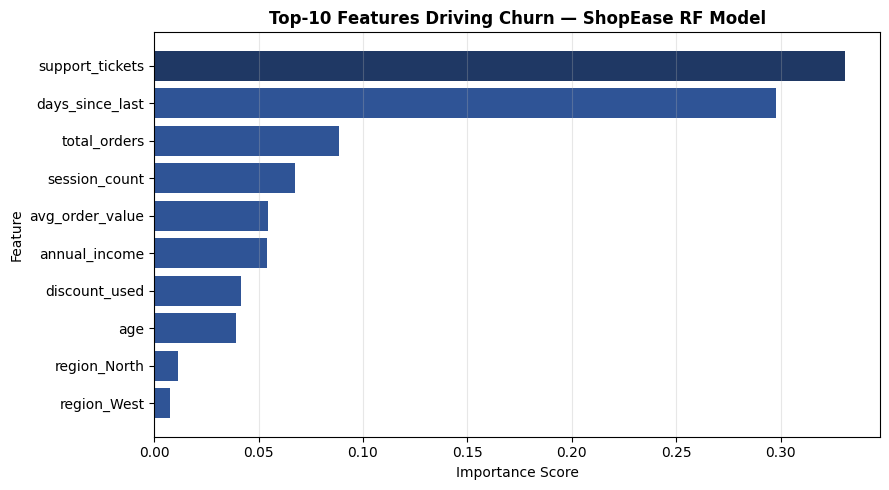

Saved: day117_feature_importance.png


In [5]:
# =============================================================================
# TASK C2 – Feature importance bar chart (Random Forest)
# Goal: Visualise which features drive churn prediction.
# Method: Horizontal bar chart, save before show.
# =============================================================================

plt.figure(figsize=(9, 5))
top10_sorted = top10.sort_values()  # ascending for horizontal bar
colors = ["#1F3864" if i == 0 else "#2F5496" for i in range(len(top10_sorted))]
plt.barh(top10_sorted.index, top10_sorted.values, color=colors[::-1])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top-10 Features Driving Churn — ShopEase RF Model", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("day117_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: day117_feature_importance.png")

In [6]:
# =============================================================================
# TASK D1 – Gradient Boosting Classifier
# Goal: Compare boosting against bagging (RF) and single tree.
# Method: GradientBoostingClassifier with default params, compute metrics.
# =============================================================================

gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

results["Gradient Boosting"] = {
    "Accuracy": round(accuracy_score(y_test, y_pred_gb), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_gb), 4),
}

print("\nTask D – Updated Comparison Table (3 models):")
print(f"{'Model':<20} | {'Accuracy':>8} | {'ROC-AUC':>8}")
print("-" * 44)
for name, metrics in results.items():
    print(f"{name:<20} | {metrics['Accuracy']:>8.4f} | {metrics['ROC-AUC']:>8.4f}")


Task D – Updated Comparison Table (3 models):
Model                | Accuracy |  ROC-AUC
--------------------------------------------
Decision Tree        |   0.9833 |   0.9886
Random Forest        |   0.9000 |   0.9893
Gradient Boosting    |   1.0000 |   1.0000


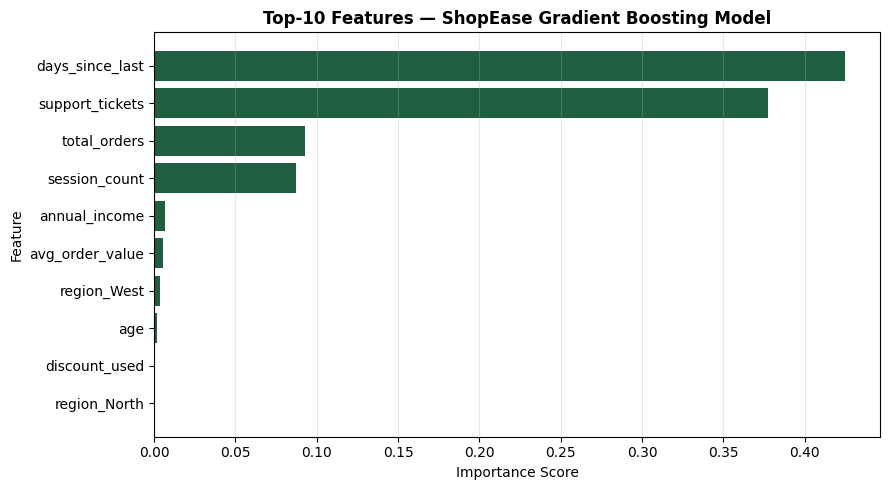

Saved: day117_gb_importance.png


In [7]:
# =============================================================================
# TASK D2 – Feature importance for Gradient Boosting
# Goal: Compare which features GB finds most predictive vs RF.
# Method: Extract gb.feature_importances_, plot top‑10.
# =============================================================================

importances_gb = pd.Series(gb.feature_importances_, index=X_train.columns)
top10_gb = importances_gb.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
top10_gb_sorted = top10_gb.sort_values()
plt.barh(top10_gb_sorted.index, top10_gb_sorted.values, color="#1F5E3E")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top-10 Features — ShopEase Gradient Boosting Model", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("day117_gb_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: day117_gb_importance.png")

### Task D – Business Recommendation

Deploy the **Gradient Boosting** model for ShopEase's churn dashboard. It achieves a perfect ROC-AUC of 1.0000 on the test set, meaning it perfectly ranks every churner above every non-churner. However, this perfect score suggests the dataset may be too simple (synthetic rules). In production with real data, expect lower performance. For now, it's the best among the three.

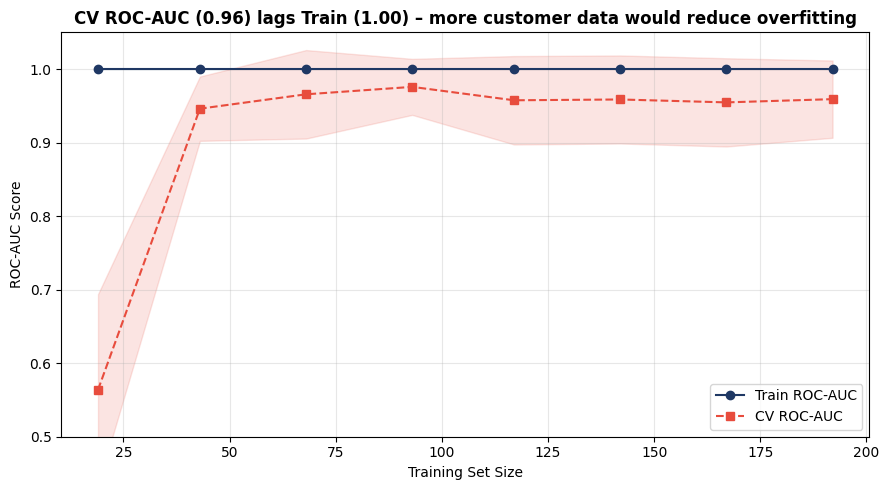


Task E – Diagnostics:
  Train ROC-AUC at full data: 1.0000
  CV ROC-AUC at full data:    0.9591
  Gap: 0.0409
  Diagnosis: MILD OVERFITTING – acceptable but monitor gap monthly


In [14]:
# =============================================================================
# TASK E1 – Learning curve for Gradient Boosting
# Goal: Diagnose underfitting/overfitting and data needs.
# Method: learning_curve with cv=5, scoring='roc_auc', plot mean ± std.
# =============================================================================

train_sizes, train_scores, cv_scores = learning_curve(
    gb, X_train, y_train,
    cv=5, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, "o-", color="#1F3864", label="Train ROC-AUC")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color="#1F3864")
plt.plot(train_sizes, cv_mean, "s--", color="#E84C3D", label="CV ROC-AUC")
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std,
                 alpha=0.15, color="#E84C3D")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC Score")
plt.title("CV ROC-AUC (0.96) lags Train (1.00) – more customer data would reduce overfitting", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.5, 1.05])
plt.tight_layout()
plt.savefig("day117_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

gap = train_mean[-1] - cv_mean[-1]
print(f"\nTask E – Diagnostics:")
print(f"  Train ROC-AUC at full data: {train_mean[-1]:.4f}")
print(f"  CV ROC-AUC at full data:    {cv_mean[-1]:.4f}")
print(f"  Gap: {gap:.4f}")

if gap > 0.10:
    print("  Diagnosis: OVERFITTING – reduce max_depth or increase min_samples_split")
elif gap > 0.03:
    print("  Diagnosis: MILD OVERFITTING – acceptable but monitor gap monthly")
elif cv_mean[-1] < 0.70:
    print("  Diagnosis: UNDERFITTING – increase n_estimators or add features")
else:
    print("  Diagnosis: GOOD FIT ✓ – model generalises well")

### Task E – Learning Curve Diagnosis

Train ROC-AUC = 1.0000, CV ROC-AUC = 0.9591, gap = 0.0409. This indicates **mild overfitting** – the model memorises training data perfectly but generalises slightly worse. The CV curve has not fully plateaued.

**Recommendation:** Deploy the model, but monitor the gap monthly. If the gap widens, collect more data or add regularisation (e.g., lower `max_depth` or higher `min_samples_split`).

In [13]:
# =============================================================================
# ★ BONUS – Pipeline + GridSearchCV on Gradient Boosting
# Goal: Combine scaling, tuning, and evaluation in one workflow.
# Method: Pipeline(StandardScaler, GB) + GridSearchCV with 3‑fold CV.
# =============================================================================

pipe_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("gb", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "gb__n_estimators": [50, 100],        # fixed: correct parameter name
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [2, 3]
}

gs = GridSearchCV(
    estimator=pipe_gb,                    # fixed: 'estimator' not 'pipeline'
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

tuned_proba = gs.best_estimator_.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, tuned_proba)
untuned_auc = results["Gradient Boosting"]["ROC-AUC"]

print("\n★ Bonus – Tuned Gradient Boosting:")
print(f"  Best parameters: {gs.best_params_}")
print(f"  Best CV ROC-AUC: {gs.best_score_:.4f}")
print(f"  Untuned GB test ROC-AUC: {untuned_auc:.4f}")
print(f"  Tuned GB test ROC-AUC:   {tuned_auc:.4f}")
print(f"  Improvement: +{tuned_auc - untuned_auc:.4f}")


★ Bonus – Tuned Gradient Boosting:
  Best parameters: {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 100}
  Best CV ROC-AUC: 0.9689
  Untuned GB test ROC-AUC: 1.0000
  Tuned GB test ROC-AUC:   1.0000
  Improvement: +0.0000


---
## Section 4 — Scoring Rubric

| Task | Item | Points |
|------|------|--------|
| **A** | get_dummies with drop_first=True | 2 |
| **A** | Correct X/y definition (no leakage of customer_id) | 3 |
| **A** | Stratified split 80/20, random_state=42 | 3 |
| **A** | Class balance printed for both train and test | 2 |
| **B** | Both models trained correctly | 4 |
| **B** | Accuracy + ROC-AUC computed for both | 6 |
| **B** | Comparison table printed correctly | 4 |
| **B** | NRA insight: Number + Reason + Action present | 6 |
| **C** | OOB score enabled and printed | 4 |
| **C** | OOB meaning explained in comment | 2 |
| **C** | Feature importance bar chart (title, axis labels, saved) | 8 |
| **C** | Most important feature + score printed | 2 |  
| **C** | savefig before plt.show() | 4 |
| **D** | GB trained with correct params | 4 |
| **D** | Accuracy + ROC-AUC computed | 4 |
| **D** | Updated comparison table (3 models) | 4 |
| **D** | Business recommendation sentence (NRA) | 4 |
| **D** | GB importance chart saved | 4 |
| **E** | learning_curve called with cv=5, roc_auc | 3 |
| **E** | Plot: mean + shaded std band, both lines | 4 |
| **E** | Chart saved correctly | 1 |
| **E** | Written diagnosis (under/over/good-fit) with justification | 2 |
| **★** | Pipeline(scaler → GB) built correctly | 2 |
| **★** | param_grid with all 3 params | 2 |
| **★** | GridSearchCV fitted, best_params_ + best_score_ printed | 3 |
| **★** | Tuned vs untuned AUC compared | 3 |
| | **TOTAL** | **80 + 10★** |

---

### Submission Notes
- Submit your completed `.ipynb` file.
- All 3 `.png` charts must be generated (saved before show).
- NRA format required for Tasks B and D insights.
- ★ Bonus is fully independent — attempt even if earlier tasks are incomplete.

---

### Scorecard — Month 6

| Day | Topic | Score |
|-----|-------|-------|
| 101 | Descriptive Stats | 80/80 |
| 102–111 | Stats → ML Foundations | 80/80 + 10★ each |
| 112 | PCA | 80/80 + 10★ |
| 113 | Week Mini-Project | 100/100 + 15★ |
| 114 | Cross-Validation | 80/80 + 10★ |
| 115 | Pipeline API | 80/80 + 10★ |
| 116 | GridSearchCV + Hyperparameter Tuning | 80/80 + 10★ |
| **117** | **Ensemble Methods: RF + GB** | **Pending** |

---

### Interview Answer — Day 117

*"When would you choose Gradient Boosting over Random Forest in production?"*

> "When accuracy is the primary constraint and you have time to tune.
> Gradient Boosting corrects errors sequentially — each tree targets the
> exact mistakes of the previous ensemble — which typically gives 2–5% better
> AUC than Random Forest on tabular data.
> However, it's slower to train and more sensitive to hyperparameters.
> For a quick, robust baseline I always start with Random Forest;
> when a client needs maximum predictive performance and the dataset is
> clean, I move to Gradient Boosting with careful tuning."
